<a href="https://colab.research.google.com/github/Kevantech/python-coursework/blob/main/Self_study_try_it_activity_23_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 23.1: Data processing for PCA

PCA is a dimensionality reduction technique that captures the highest possible variance from a set number of dimensions. Additionally, it will find the projection that minimises the sum of the squared distances between the original and the projected data points.

In [1]:
#Import the necessary libraries
import numpy.random as rand
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


Below is a simulated data set (shown in blue) that has been projected onto four different components (shown in orange).

Which of these projections maximises the variance of the data that is kept and is likely to be the principal component?

This activity helps you visually identify the direction that captures the most variance – an essential concept in understanding how PCA selects principal components.

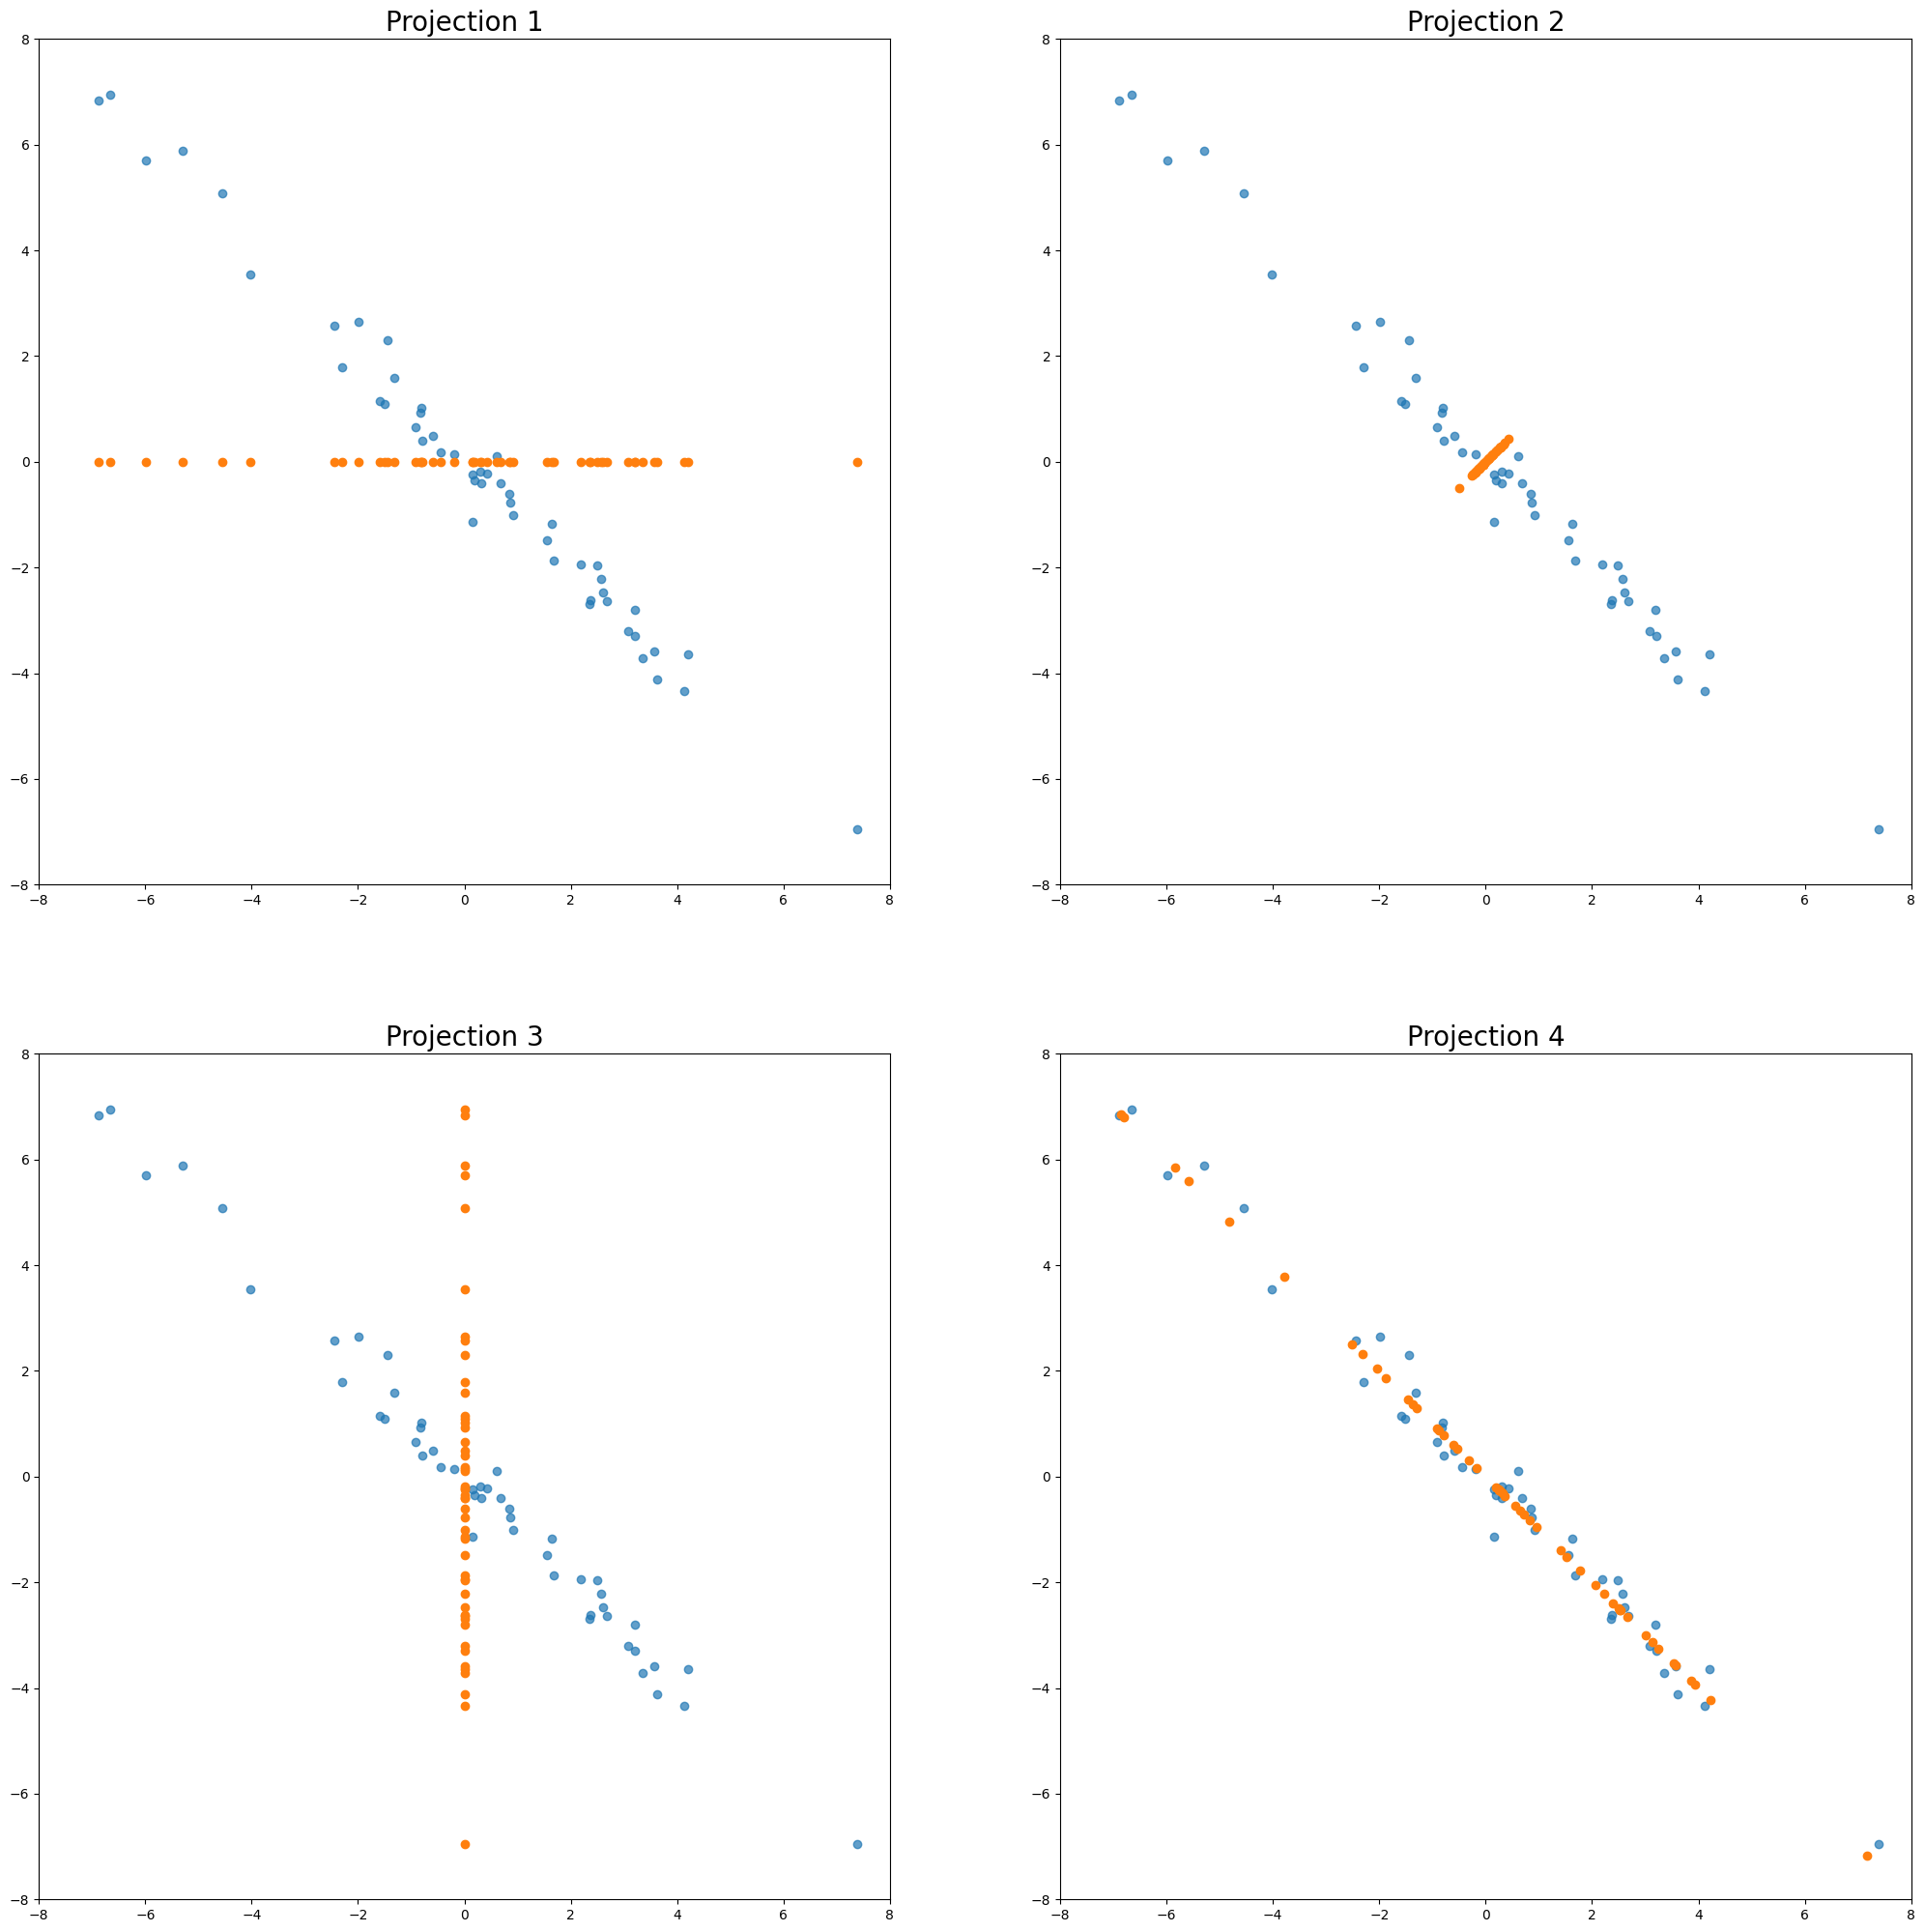

In [2]:
rand.seed(1234)

x1 = 3 * np.outer(rand.normal(0,1,50), np.array([1,-1]))
x2 = rand.multivariate_normal([0,0],np.diag([0.1,0.1]), size = 50)

X = x1 + x2

projection = np.array((1,0)).reshape((2,1))

R = np.matrix([[1/np.sqrt(2), -1/np.sqrt(2)], [1/np.sqrt(2), 1/np.sqrt(2)]])

fig, axs = plt.subplots(2,2, figsize = (25,25))
for i in range(4):
    axs[i//2, i % 2 ].set_xlim([-8,8])
    axs[i//2, i % 2 ].set_ylim([-8,8])
    axs[i//2, i % 2 ].scatter(X[:,0], X[:,1], alpha = 0.7)
    axs[i//2, i % 2 ].title.set_text("Projection %s" % (i+1))
    axs[i//2, i % 2 ].title.set_size(20)
    scores = X @ projection
    Xi = np.outer(scores, projection)
    axs[i//2, i % 2 ].scatter(Xi[:,0],Xi[:,1])
    projection = R @ projection

plt.show()


 ### To-do 1:
 Which of these projections maximises the variance of the data that is kept and is likely to be the principal component?

* Projection 1
* Projection 2
* Projection 3
* Projection 4


### Type your answer here:

**Answer: Projection 4.**

The simulated data is generated along the direction $(1, -1)$ (via `np.outer(rand.normal(0,1,50), np.array([1,-1]))`), so the cloud of points stretches diagonally from the upper left to the lower right. The rotation matrix `R` rotates the projection direction by 45° each iteration:

* Projection 1: direction $(1, 0)$ — horizontal axis, captures only part of the spread.
* Projection 2: direction $(1, 1)/\sqrt{2}$ — perpendicular to the data's main axis, so the projected points collapse near the origin (minimum variance).
* Projection 3: direction $(0, 1)$ — vertical axis, again only partial spread.
* Projection 4: direction $(-1, 1)/\sqrt{2}$ — parallel to the data's main axis $(1,-1)$, so the projected points spread out along the full length of the cloud.

Because Projection 4 is aligned with the direction of maximum spread, it retains the highest variance and is the one PCA would select as the first principal component.

## Dimensionality reduction with PCA

PCA is commonly used to reduce the dimensionality of high-dimensional data sets by selecting a subset of components that retain most of the original variance. This technique is particularly valuable when preparing data for machine learning models, as it can improve training efficiency and model generalisation.

In this notebook, you will work with a data set comprising S&P 500 stock prices over the past five years. Given the high degree of correlation among stocks in the market, retaining all individual stock features may introduce redundancy and unnecessarily increase model complexity and training time.

Instead, PCA allows you to project the data onto a smaller set of orthogonal components that capture the majority of the variance. This approach simplifies the feature space while preserving the underlying structure, making it a more effective input for downstream modelling tasks.


In [3]:

df = pd.read_csv("all_stocks_5yr.csv")

names = df["Name"].unique()
range(len(df[ df["Name"] == names[0]]["close"]))
l = len(df[ df["Name"] == names[0]]["close"])
data = pd.DataFrame(index = range(l), columns= names)

for name in names:
    x = df[ df["Name"] == name]["close"]
    if x.isnull().any() or len(x) != l:
        data = data.drop(columns= name)
    else:
        data[name] = np.array(x)

data = data.astype(float) #Ensure numeric dtype for PCA
data.head()





,AAL,AAPL,AAP,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,...,XLNX,XL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
0,14.75,67.8542,78.90,36.25,46.89,34.41,73.31,39.12,45.70,30.22,...,37.51,28.24,88.61,42.87,31.84,27.09,65.30,75.85,24.14,33.05
1,14.46,68.5614,78.39,35.85,46.76,34.26,73.07,38.64,46.08,30.28,...,37.46,28.31,88.28,42.84,31.96,27.46,64.55,75.65,24.21,33.26
2,14.27,66.8428,78.60,35.42,46.96,34.30,73.37,38.89,46.27,30.81,...,37.58,28.41,88.46,42.87,31.84,27.95,64.75,75.44,24.49,33.74
3,14.66,66.7156,78.97,35.27,46.64,34.46,73.56,38.81,46.26,31.16,...,37.80,28.42,88.67,43.08,32.00,28.26,64.41,76.00,24.74,33.55
4,13.99,66.6556,78.84,36.57,46.77,34.70,73.13,38.61,46.54,31.40,...,38.44,28.22,88.52,42.91,32.12,28.47,63.89,76.34,24.63,33.27


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The above code cell loads five years of S&P 500 stock data and constructs a clean data frame of closing prices, excluding stocks with missing values or inconsistent time series lengths. The result is a well-aligned data set suitable for analysis or modelling.

## Interpreting the scree plot

The scree plot below displays the proportion of variance explained by each of the first ten principal components derived from the PCA of the stock data set. This visualisation is a key tool for determining the optimal number of components to retain.

Your task is to analyse the scree plot and decide how many principal components you would keep to effectively represent the data set while minimising dimensionality. Consider both the individual and cumulative variance explained and identify the 'elbow point' – the point beyond which additional components contribute marginally to the total variance.

### To-do 2:

Based on the scree plot of the first ten principal components from the PCA and any additional analysis you consider appropriate, how many components would you retain to effectively represent this data set, and what is your rationale for that choice?


Component 1 
Fraction of total variance explained by this variable: 0.783705370360257 
 Total fraction of variance explained by the first 1 variable(s): 0.783705370360257

Component 2 
Fraction of total variance explained by this variable: 0.09162218072840872 
 Total fraction of variance explained by the first 2 variable(s): 0.8753275510886658

Component 3 
Fraction of total variance explained by this variable: 0.05430341223767854 
 Total fraction of variance explained by the first 3 variable(s): 0.9296309633263443

Component 4 
Fraction of total variance explained by this variable: 0.02084533802414898 
 Total fraction of variance explained by the first 4 variable(s): 0.9504763013504933

Component 5 
Fraction of total variance explained by this variable: 0.012893002325176692 
 Total fraction of variance explained by the first 5 variable(s): 0.96336930367567

Component 6 
Fraction of total variance explained by this variable: 0.008528095295358334 
 Total fraction of variance explained 

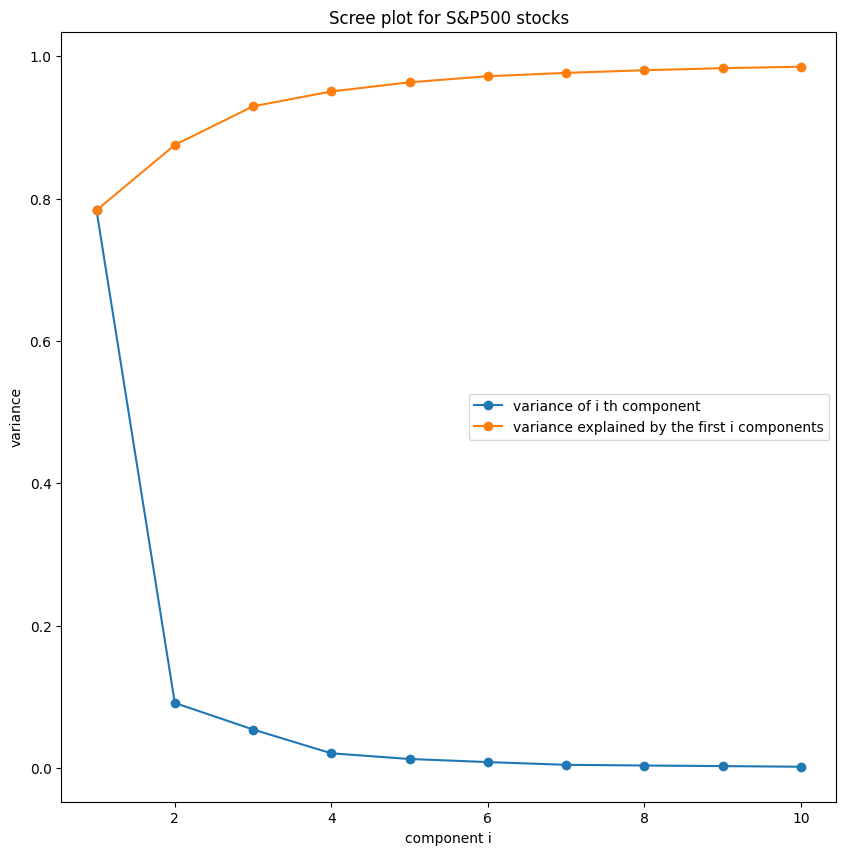

In [5]:
pca = PCA(10).fit(data)
var = pca.explained_variance_ratio_
var_explained = np.zeros(10)
for i in range(10):
    var_explained[i] = sum(var[:i+1])

for i in range(10):
    print("\nComponent", i+1 , "\nFraction of total variance explained by this variable:", var[i],
            "\n Total fraction of variance explained by the first %s variable(s):" % (i +1), var_explained[i] )

plt.figure(figsize = (10,10))
plt.plot(range(1, len(var_explained)+1), var, label = "variance of i th component", marker = "o")
plt.plot(range(1, len(var_explained)+1), var_explained, label = "variance explained by the first i components", marker = "o")
plt.xlabel("component i")
plt.ylabel("variance")
plt.title("Scree plot for S&P500 stocks")
plt.legend()
plt.show()




### Type your answer here:

**Answer: I would retain 3 components.**

From the scree plot and the printed output on the raw (unstandardised) data:

* Component 1 alone explains about **78.4%** of the total variance.
* Component 2 adds ~9.2% (cumulative ≈ **87.5%**).
* Component 3 adds ~5.4% (cumulative ≈ **93.0%**).
* Component 4 adds only ~2.1%, and every component after that contributes less than 2% each.

The 'elbow' of the scree plot occurs at component 3: up to that point each component adds a meaningful share of variance, but from component 4 onward the curve flattens and the marginal gain becomes negligible. Retaining 3 components keeps roughly 93% of the total variance while reducing the feature space from 470 stocks to just 3 dimensions — an excellent trade-off between compactness and information retained.

## Pre-processing the data

When analysing which stocks contribute most to the principal components, it's important to consider how the data was pre-processed. If you apply PCA directly to the raw closing prices, stocks with higher average prices dominate the principal components in raw data because PCA is sensitive to scale. This can lead to misleading interpretations, as variance may reflect price magnitude rather than meaningful movement.

In most financial analyses, you are more interested in **relative variability**, which means how much a stock's price fluctuates in proportion to its own value rather than its absolute magnitude. A high variance driven by a large price scale does not necessarily indicate meaningful movement or volatility.

To ensure a fair and interpretable PCA, you standardise the data so that each stock has a **mean of zero** and a **variance of one**. This transformation allows PCA to focus on patterns of variation that are comparable across stocks, regardless of their original price levels, leading to more meaningful insights.


## Re-evaluating component selection

### To-do 3:

Examine the scree plot provided below. Based on its structure and the variance explained by each principal component, can you reasonably assume that the same number of components should be retained as in your previous PCA? Consider whether the distribution of variance has changed and justify your conclusion with reference to the plot.


Component 1
Fraction of total variance explained by this component:0.5831
Total fraction of variance explained by the first 1 component(s): 0.5831

Component 2
Fraction of total variance explained by this component:0.1492
Total fraction of variance explained by the first 2 component(s): 0.7323

Component 3
Fraction of total variance explained by this component:0.1014
Total fraction of variance explained by the first 3 component(s): 0.8337

Component 4
Fraction of total variance explained by this component:0.0387
Total fraction of variance explained by the first 4 component(s): 0.8724

Component 5
Fraction of total variance explained by this component:0.0252
Total fraction of variance explained by the first 5 component(s): 0.8976

Component 6
Fraction of total variance explained by this component:0.0190
Total fraction of variance explained by the first 6 component(s): 0.9166

Component 7
Fraction of total variance explained by this component:0.0132
Total fraction of variance explained 

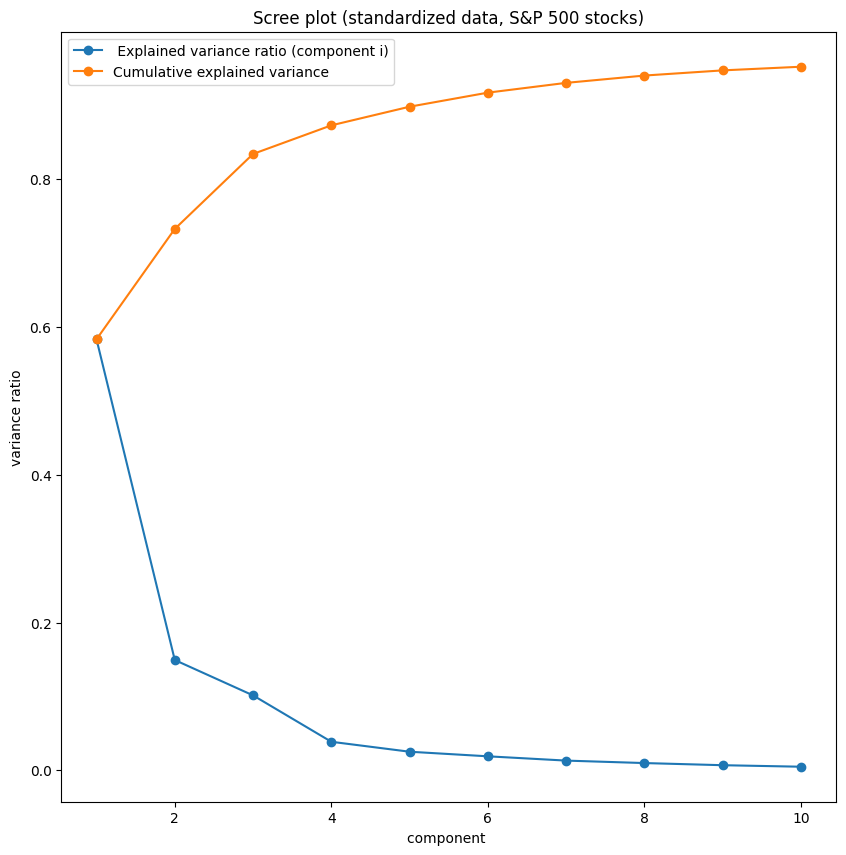

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(data)


data_scaled = scaler.transform(data)

#Number of component guards (optional but safer)
n_comp = min(10, data_scaled.shape[1])
pca_scaled = PCA(n_comp).fit(data_scaled)
var_scaled = pca_scaled.explained_variance_ratio_
var_scaled_explained = np.cumsum(var_scaled)

#Print the scaled values you just computed
for i in range(n_comp):
    print(
            f"\nComponent {i+1}"
            f"\nFraction of total variance explained by this component:{var_scaled[i]:.4f}"
            f"\nTotal fraction of variance explained by the first {i+1} component(s): {var_scaled_explained[i]:.4f}"
        )
#Plot using the scaled arrays for both series and axis length
plt.figure(figsize=(10, 10))
plt.plot(range(1, n_comp+1), var_scaled, marker="o", label=" Explained variance ratio (component i)")
plt.plot(range(1, n_comp+1), var_scaled_explained, marker="o", label="Cumulative explained variance")
plt.xlabel("component ")
plt.ylabel("variance ratio")
plt.title("Scree plot (standardized data, S&P 500 stocks)")
plt.legend()
plt.show()

### Type your answer here:

**Answer: No — the same choice of 3 components is no longer clearly adequate; the standardised data spreads variance across more components, so I would retain more (around 4–6).**

After standardisation the variance distribution changes noticeably:

* Component 1 now explains only about **58.3%** (down from 78.4% on the raw data).
* The first 3 components explain about **83.4%** cumulatively (versus ~93.0% before).
* To reach the same ~93% level captured by 3 raw components, roughly **6–7 components** are now needed (cumulative ≈ 91.7% at 6, 93.0% at 7).

This happens because standardisation gives every stock equal weight. On raw prices, a handful of high-priced stocks (e.g. large absolute price movements) dominated the first component, artificially concentrating the variance. Once each stock is scaled to unit variance, the genuine co-movement structure of the market is more evenly spread, so each additional component carries more meaningful information. The elbow is softer and located slightly further right, which justifies retaining more components than in the previous analysis.

## Comparing PCA results: raw vs pre-processed data

Applying PCA to raw versus pre-processed data can yield significantly different principal components. This distinction is illustrated below through two key observations:

1. **Top-contributing stocks**:  
   When you examine the five stocks that contribute most to the first principal component, you find that the results differ between the raw and standardised data sets. This indicates that the PCA model identifies different sources of variance depending on whether the data has been scaled.

2. **Score distribution across components**:  
   The plots of scores along the first two principal components may appear visually similar, but the underlying scales differ substantially. In the standardised data, features are adjusted to have equal variance, which can amplify or compress certain patterns. This transformation leads to a more balanced and interpretable representation of the data structure.

These differences highlight the importance of pre-processing when applying PCA, especially in contexts where feature magnitudes vary widely.


### To-do 4:

Imagine you are an investor planning to allocate capital across S&P 500 stocks based on their weights in the first principal component derived from historical data. However, recognising the potential risk due to high variance in returns, you decide to mitigate this by splitting your investment: half based on the first principal component and half based on the second, which is uncorrelated with the first and exhibits lower variance.

Given this strategy, would it be more appropriate to derive the principal components from the **raw data** or from **pre-processed (standardized) data**? Justify your answer regarding interpretability, risk, and the nature of PCA.


Largest 5 contributors to the principal component of unpreprocessed data: Index(['PCLN', 'AMZN', 'GOOGL', 'MTD', 'EQIX'], dtype='object')
Largest 5 contributors to the principal component of preprocessed data: Index(['CTAS', 'BDX', 'AVGO', 'LMT', 'NOC'], dtype='object')


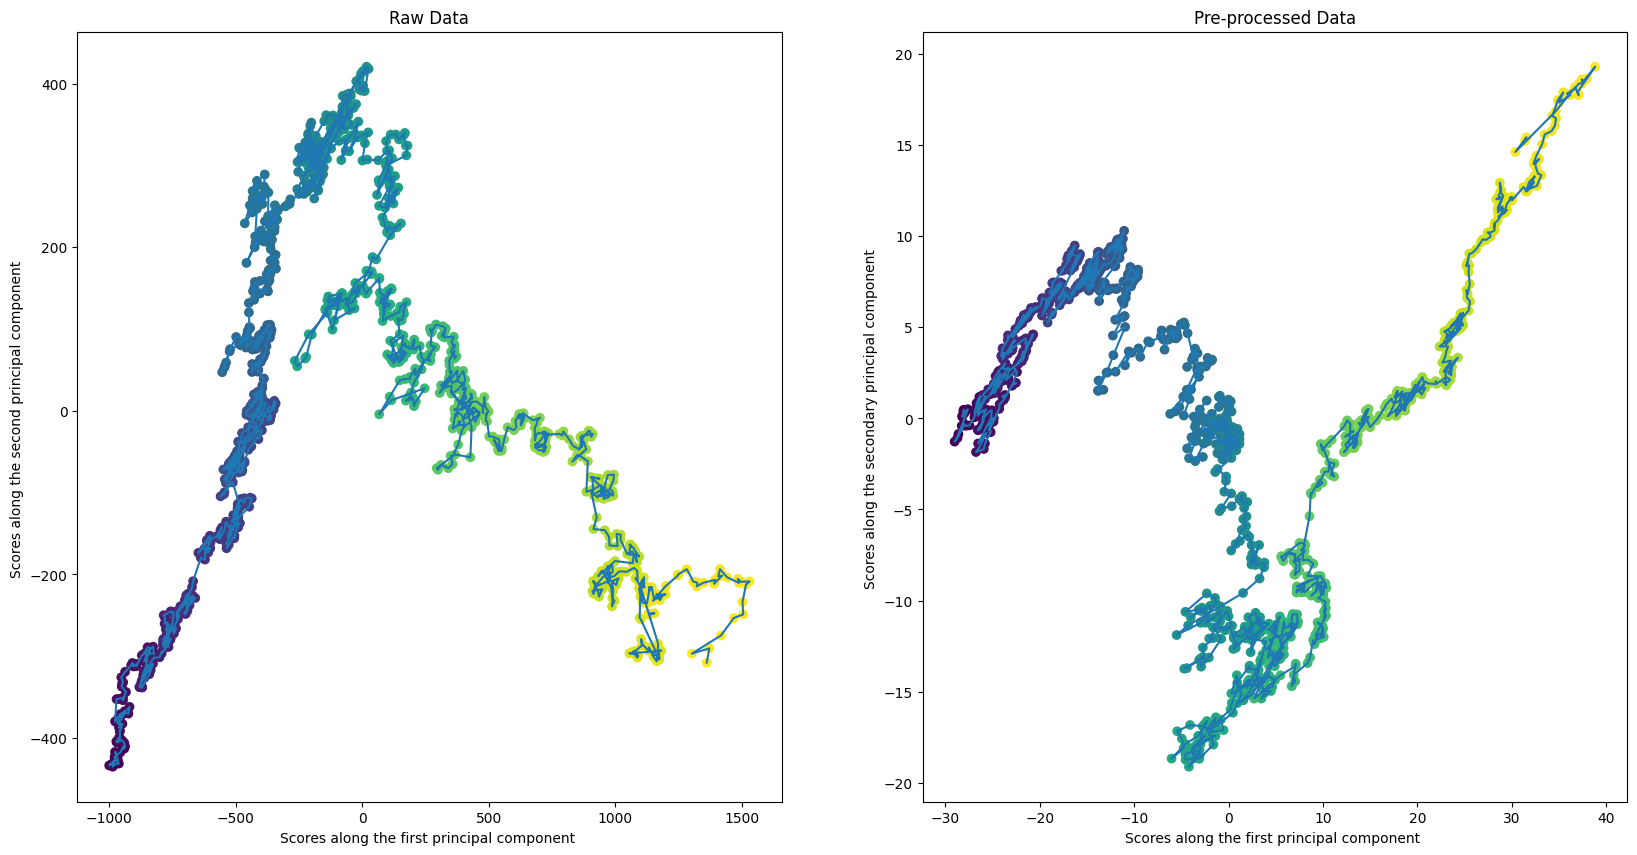

83.69295150457137


In [7]:
stocks = data.columns[np.argsort(pca.components_[0])[-1:-6:-1]]

print("Largest 5 contributors to the principal component of unpreprocessed data:", stocks)

stocks_scaled = data.columns[np.argsort(pca_scaled.components_[0])[-1:-6:-1]]

print("Largest 5 contributors to the principal component of preprocessed data:", stocks_scaled)

fig, axs = plt.subplots(1,2, figsize = (20,10))
axs[0].plot(pca.transform(data)[:,0],pca.transform(data)[:,1])
axs[0].scatter(pca.transform(data)[:,0],pca.transform(data)[:,1], c = np.arange(l)/l)
axs[1].plot(pca_scaled.transform(data_scaled)[:,0],pca_scaled.transform(data_scaled)[:,1])
axs[1].scatter(pca_scaled.transform(data_scaled)[:,0],pca_scaled.transform(data_scaled)[:,1], c = np.arange(l)/l)
axs[0].set_title("Raw Data")
axs[1].set_title("Pre-processed Data")
axs[0].set_xlabel("Scores along the first principal component ")
axs[0].set_ylabel("Scores along the second principal component ")
axs[1].set_xlabel("Scores along the first principal component ")
axs[1].set_ylabel("Scores along the secondary principal component ")
plt.show()
print(np.mean(data))

### Type your answer here:

**Answer: The pre-processed (standardised) data is the appropriate choice for this investment strategy.**

* **Interpretability:** On raw data, the first principal component is dominated by high-priced stocks (the top contributors are PCLN, AMZN, GOOGL, MTD, EQIX — all expensive stocks), simply because PCA on raw prices rewards large absolute price levels, not meaningful market behaviour. On standardised data the leading contributors (e.g. CTAS, BDX, AVGO, LMT, NOC) reflect stocks whose *relative* movements best track the common market factor. An allocation based on raw-data weights would effectively just be a bet on expensive stocks.

* **Risk:** The strategy explicitly splits capital between PC1 and PC2 to diversify, relying on the fact that the components are uncorrelated and that PC2 has lower variance. That diversification argument only makes sense if variance is measured on a comparable scale across stocks. With raw data, 'variance' mostly encodes price magnitude, so the risk decomposition is distorted; with standardised data, variance reflects genuine relative volatility, so PC1 captures broad market risk and PC2 a genuinely distinct, lower-risk factor.

* **Nature of PCA:** PCA is scale-sensitive. Standardising ensures every stock contributes on equal footing, so the orthogonality and variance ordering of the components describe the correlation structure of returns rather than arbitrary price units. This is exactly the structure the investor's strategy depends on.

In short, standardised data gives component weights that are economically meaningful, a risk split that is genuine, and a portfolio that is diversified across market factors rather than concentrated in nominally expensive stocks.